# CIFAR-10 Image Classification with ResNet18
This notebook trains a ResNet18 model on the CIFAR-10 dataset using PyTorch with GPU acceleration.

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f'PyTorch Version : {torch.__version__}')
print(f'CUDA Available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch Version : 2.6.0+cu124
CUDA Available  : True
GPU             : NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Configuration

In [2]:
# --- Config ---
BATCH_SIZE  = 32       # Keep at 32 for 4GB VRAM (RTX 3050)
NUM_EPOCHS  = 10
LR          = 1e-4
NUM_CLASSES = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

Using device: cuda


## 3. Load & Preprocess CIFAR-10

In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Changed from 224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

transform_test = transforms.Compose([
    transforms.ToTensor(), # Removed Resize
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

# Download CIFAR-10 (downloads to ./data folder)
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform_train)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Training samples  : {len(train_dataset)}')
print(f'Test samples      : {len(test_dataset)}')
print(f'Training batches  : {len(train_loader)}')
print(f'Test batches      : {len(test_loader)}')

d:\Metamorphic\cifar_resnet\cifar_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples  : 50000
Test samples      : 10000
Training batches  : 1563
Test batches      : 313


## 4. Visualize Sample Images

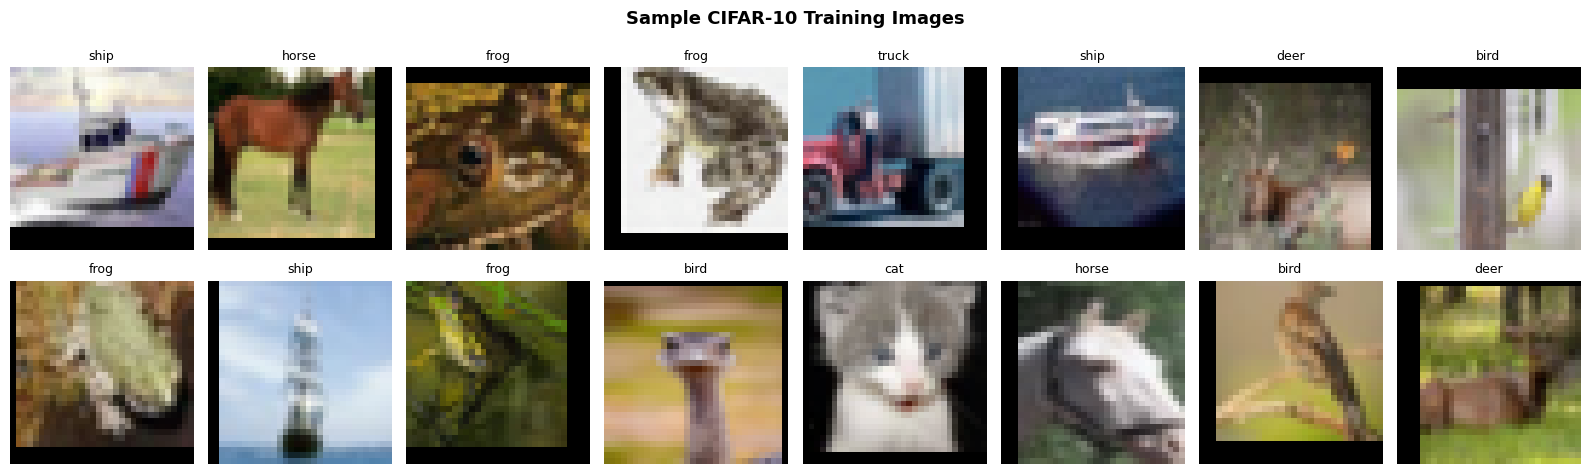

In [4]:
def imshow(img):
    """Unnormalize and display an image."""
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img  = img.numpy().transpose((1, 2, 0))
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    return img

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imshow(images[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Load ResNet18 Model

In [5]:
model = resnet18(weights=None) # We must train from scratch for modified architecture

# Modify the first layer to accept 32x32 images without shrinking them too fast
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity() # Remove the maxpool layer entirely

# Change the final output layer to 10 classes
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

# Print model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

Total parameters     : 11,173,962
Trainable parameters : 11,173,962


## 6. Loss, Optimizer & Scheduler

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Mixed precision scaler — saves VRAM on your RTX 3050
scaler = torch.cuda.amp.GradScaler()

C:\Users\jenis\AppData\Local\Temp\ipykernel_32240\872480718.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


## 7. Training & Evaluation Functions

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / len(loader.dataset)
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / len(loader.dataset)
    return avg_loss, accuracy

## 8. Train the Model

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>12} {'Val Loss':>10} {'Val Acc':>10}")
print('-' * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6}/{NUM_EPOCHS} {train_loss:>12.4f} {train_acc:>11.2f}% {val_loss:>10.4f} {val_acc:>9.2f}%")

print('-' * 58)
print(f'Best Val Accuracy: {max(history["val_acc"]):.2f}%')

 Epoch   Train Loss    Train Acc   Val Loss    Val Acc
----------------------------------------------------------


## 9. Plot Training Curves

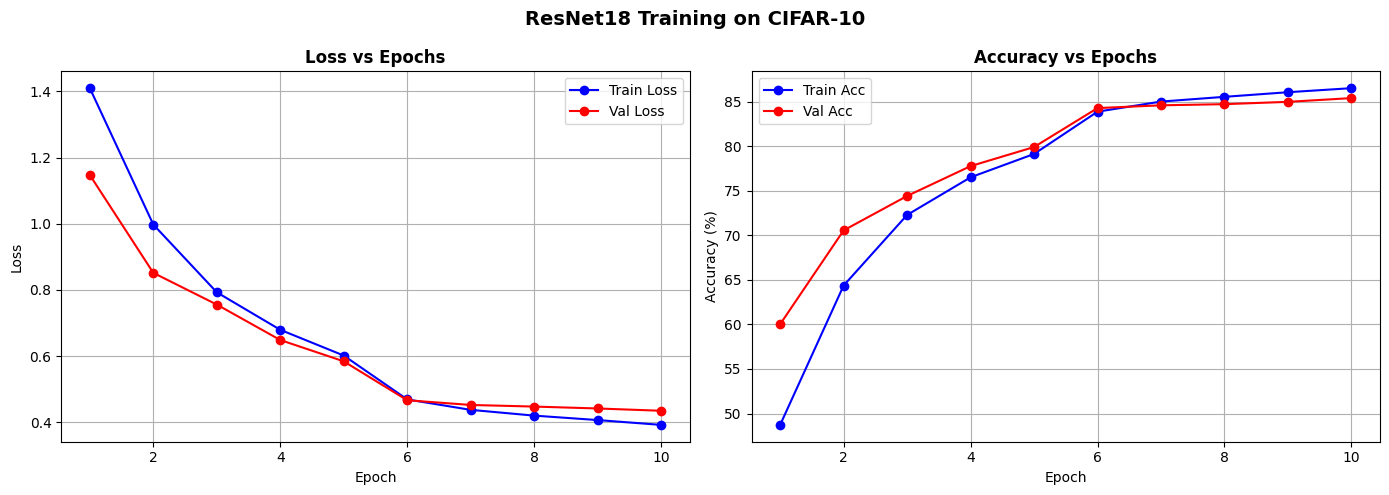

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
ax1.set_title('Loss vs Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'],   'r-o', label='Val Acc')
ax2.set_title('Accuracy vs Epochs', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('ResNet18 Training on CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Per-Class Accuracy

Class            Correct    Total   Accuracy
---------------------------------------------
airplane             899     1000     89.90%
automobile           946     1000     94.60%
bird                 790     1000     79.00%
cat                  703     1000     70.30%
deer                 808     1000     80.80%
dog                  765     1000     76.50%
frog                 903     1000     90.30%
horse                881     1000     88.10%
ship                 942     1000     94.20%
truck                902     1000     90.20%


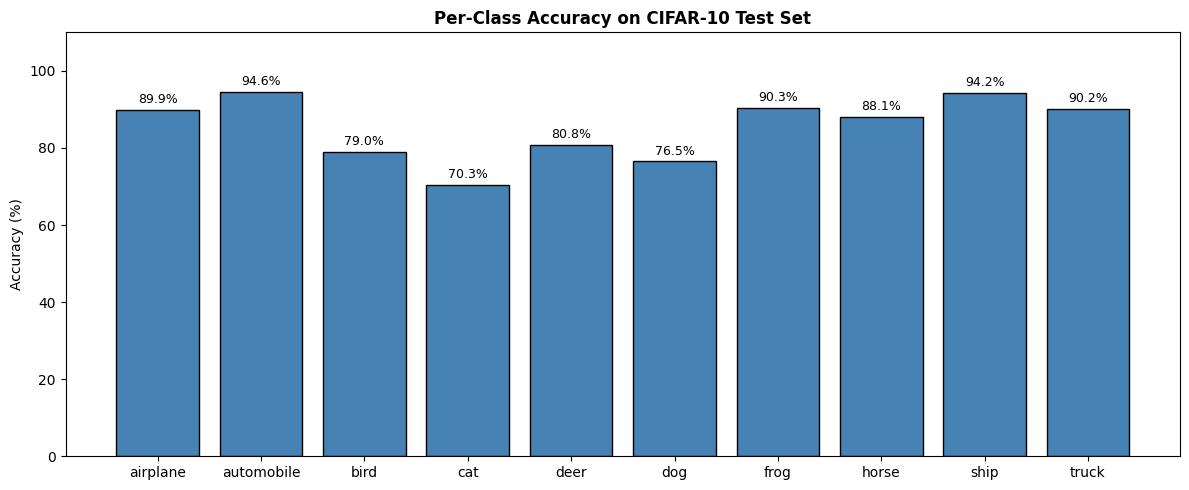

In [ ]:
model.eval()
class_correct = [0] * NUM_CLASSES
class_total   = [0] * NUM_CLASSES

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = model(images)
        preds    = outputs.argmax(1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (preds[i] == labels[i]).item()
            class_total[label]   += 1

print(f"{'Class':<15} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print('-' * 45)
for i in range(NUM_CLASSES):
    acc = 100.0 * class_correct[i] / class_total[i]
    print(f"{CLASSES[i]:<15} {class_correct[i]:>8} {class_total[i]:>8} {acc:>9.2f}%")

# Bar chart
accs = [100.0 * class_correct[i] / class_total[i] for i in range(NUM_CLASSES)]
plt.figure(figsize=(12, 5))
bars = plt.bar(CLASSES, accs, color='steelblue', edgecolor='black')
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy on CIFAR-10 Test Set', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Save the Model

In [ ]:
torch.save(model.state_dict(), 'resnet18_cifar10.pth')
print('Model saved to resnet18_cifar10.pth')

Model saved to resnet18_cifar10.pth


## 12. Load Model & Run Inference on a Single Image

In [ ]:
# Load saved model — must match the architecture used during training
loaded_model = resnet18(weights=None)

# Apply the same CIFAR-10 modification as training
loaded_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
loaded_model.maxpool = nn.Identity()  # Remove maxpool for small images
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, NUM_CLASSES)

# Now load the weights
loaded_model.load_state_dict(torch.load('resnet18_cifar10.pth', map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully!")

# Pick a random test image
idx = np.random.randint(0, len(test_dataset))
image, true_label = test_dataset[idx]

with torch.no_grad():
    output = loaded_model(image.unsqueeze(0).to(device))
    pred   = output.argmax(1).item()

# Display
plt.figure(figsize=(4, 4))
plt.imshow(imshow(image))
color = 'green' if pred == true_label else 'red'
plt.title(f'Predicted: {CLASSES[pred]}\nActual: {CLASSES[true_label]}',
          color=color, fontweight='bold')
plt.axis('off')
plt.show()

RuntimeError: Error(s) in loading state_dict for ResNet:
	size mismatch for conv1.weight: copying a param with shape torch.Size([64, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([64, 3, 7, 7]).